# Neural Architecture Search (NAS) - let the search pick the architecture

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khanhnd61-vr/modelopt-101/blob/main/examples/04_nas/nas.ipynb)

**Goal.** Instead of hand-designing a network, **define a space of possible networks and search
it** for one with a good accuracy / cost trade-off.

Two things define a NAS:

1. **The search space** - what is allowed to vary (here: depth, channel width, kernel size).
2. **The search strategy** - how we explore that space (here: *random search* vs. a simple
   *evolutionary search*).

Training every candidate fully is too slow, so the search ranks candidates with a **cheap
proxy**: train each for a couple of epochs on a data subset. We use **model size as the cost**
during the search (cheap, and a decent stand-in for latency), then measure real size, accuracy
and CPU latency on the finalists.

**Runtime:** set `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`.
Full run is a few minutes on a Colab GPU.

## 1. Setup

On Colab `torch`/`torchvision` are pre-installed, so nothing to `pip install`.

In [6]:
import io, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --- knobs you can play with ---
EPOCHS        = 10      # full training for the finalists (before vs. after)
SEARCH_EPOCHS = 2       # cheap proxy training per candidate during the search
SEARCH_SUBSET = 10000   # images used by the proxy (smaller = faster search)
BATCH_SIZE    = 128
LR            = 0.05
N_RANDOM      = 8       # candidates drawn by random search
EVO_GENS      = 2       # evolutionary generations
EVO_CHILDREN  = 4       # mutated children per generation

device: cuda


## 2. Data - MNIST

10 classes (handwritten digits 0-9) of 28x28 grayscale images. We also carve out a small
**subset** used only for the cheap proxy training during the search.

In [7]:
mean = (0.1307,)
std  = (0.3081,)

train_tf = T.Compose([
    T.RandomCrop(28, padding=2),
    T.ToTensor(),
    T.Normalize(mean, std),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

train_set = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=256,        shuffle=False, num_workers=2)

# small subset for the cheap proxy training during search
sub_idx       = torch.randperm(len(train_set))[:SEARCH_SUBSET].tolist()
search_loader = DataLoader(Subset(train_set, sub_idx), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2)

print(len(train_set), "train /", len(test_set), "test /", len(sub_idx), "search-subset")

60000 train / 10000 test / 10000 search-subset


## 3. The search space 🔑

An architecture is just three **genes**: how deep, how wide, and the kernel size. `build_model`
turns a choice of genes into an actual network. The whole point of NAS is that we never commit
to one set of genes by hand - we let the search choose.

In [8]:
# what each architecture gene can be
CHOICES = {
    "depth":  [2, 3, 4],            # number of conv stages
    "width":  [8, 12, 16, 24, 32],  # channels in the first stage (doubles each stage, capped)
    "kernel": [3, 5],               # conv kernel size
}

def build_model(arch, num_classes=10):
    layers, cin = [], 1
    # TODO: build the net from the genes: loop range(arch["depth"]); k = arch["kernel"];
    #       cout = min(arch["width"] * (2 ** i), 128)
    for i in range(arch["depth"]):
        cout = min(arch["width"] * (2 ** i), 128)
        k = arch["kernel"]
        layers += [nn.Conv2d(cin, cout, k, padding=k // 2, bias=False),
                   nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                   nn.MaxPool2d(2)]                     # 28 -> 14 -> 7 -> 3 ...
        cin = cout
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(cin, num_classes)]
    return nn.Sequential(*layers)

def random_arch():
    return {g: random.choice(opts) for g, opts in CHOICES.items()}

def arch_key(a): return (a["depth"], a["width"], a["kernel"])
def arch_str(a): return f"d{a['depth']}-w{a['width']}-k{a['kernel']}"

space_size = int(np.prod([len(v) for v in CHOICES.values()]))
print(f"search space: {space_size} architectures")
print("example:", arch_str(random_arch()))

search space: 30 architectures
example: d3-w24-k3


## 4. Train / eval / metric utilities

The same loops as the other exercises. `train` takes a data loader so it serves both the cheap
proxy (subset, few epochs) and the full finalist training. Plus an evaluator, a single-image
**CPU** latency probe, and an on-disk size probe.

In [9]:
def count_params(m):
    return sum(p.numel() for p in m.parameters())

def train(model, loader, epochs, lr=LR, tag=""):
    model.to(device).train()
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            F.cross_entropy(model(x), y).backward()
            opt.step()
        sched.step()
    return model

@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.numel()
    model.train()
    return 100.0 * correct / total

@torch.no_grad()
def latency_ms(model, n=100):
    """Average single-image inference latency on CPU (ms)."""
    model = copy.deepcopy(model).to("cpu").eval()
    x = torch.randn(1, 1, 28, 28)
    for _ in range(10):            # warmup
        model(x)
    t0 = time.time()
    for _ in range(n):
        model(x)
    return (time.time() - t0) / n * 1000.0

def model_size_mb(model):
    """On-disk size of the saved weights (MB)."""
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.getbuffer().nbytes / 1e6

## 5. Search strategy: random search 🔑

The simplest strategy: **draw random architectures and score each one**. Scoring is the cheap
proxy - train on the subset for a couple of epochs and read off test accuracy. We record the
proxy accuracy and the model size for every candidate we touch.

In [10]:
def proxy_eval(arch):
    """Cheap fitness: quick-train on the subset, return (accuracy, size_MB)."""
    model = build_model(arch)
    # TODO: quick-train the proxy before scoring -> train(model, search_loader, epochs=SEARCH_EPOCHS)
    model = train(model, search_loader, epochs=SEARCH_EPOCHS)
    return evaluate(model), model_size_mb(model)

results = []          # every architecture we evaluate ends up here
seen = set()

def consider(arch, source):
    if arch_key(arch) in seen:            # don't pay to retrain a duplicate
        return
    seen.add(arch_key(arch))
    acc, size = proxy_eval(arch)
    results.append({"arch": arch, "acc": acc, "size": size, "source": source})
    print(f"  {arch_str(arch):<12} proxy_acc={acc:5.2f}%  size={size:5.2f}MB  [{source}]")

print("random search:")
while sum(r["source"] == "random" for r in results) < N_RANDOM:
    consider(random_arch(), "random")

random search:
  d3-w32-k5    proxy_acc=97.39%  size= 1.04MB  [random]
  d3-w16-k5    proxy_acc=94.87%  size= 0.27MB  [random]
  d3-w32-k3    proxy_acc=95.27%  size= 0.38MB  [random]
  d4-w12-k5    proxy_acc=98.05%  size= 0.62MB  [random]
  d2-w8-k5     proxy_acc=74.94%  size= 0.02MB  [random]
  d4-w32-k3    proxy_acc=98.15%  size= 0.98MB  [random]
  d3-w8-k3     proxy_acc=93.73%  size= 0.03MB  [random]
  d4-w16-k5    proxy_acc=97.88%  size= 1.09MB  [random]


## 6. Search strategy: evolutionary search 🔑

Random search is blind. Evolution is a little smarter: **take the best architectures so far and
mutate them** (change one gene), spending the budget near regions that already look good. After
each generation the parents are re-picked from everything evaluated, random and evolved alike.

In [11]:
def mutate(arch):
    child = dict(arch)
    # TODO: change one random gene to a different allowed value:
    #       gene = random.choice(list(CHOICES))
    #       child[gene] = random.choice([v for v in CHOICES[gene] if v != arch[gene]])
    gene = random.choice(list(CHOICES))
    child[gene] = random.choice([v for v in CHOICES[gene] if v != arch[gene]])
    return child

print("evolutionary search:")
for gen in range(EVO_GENS):
    # TODO: parents = the 2 highest-acc archs so far -> sorted(results, key=lambda r: r["acc"], reverse=True)[:2]
    parents = sorted(results, key=lambda r: r["acc"], reverse=True)[:2]
    print(f" generation {gen + 1}: parents = {[arch_str(p['arch']) for p in parents]}")
    for _ in range(EVO_CHILDREN):
        consider(mutate(random.choice(parents)["arch"]), "evolved")

evolutionary search:
 generation 1: parents = ['d4-w32-k3', 'd4-w12-k5']
  d4-w24-k3    proxy_acc=97.83%  size= 0.67MB  [evolved]
  d4-w12-k3    proxy_acc=97.91%  size= 0.23MB  [evolved]
  d4-w24-k5    proxy_acc=96.50%  size= 1.83MB  [evolved]
  d4-w32-k5    proxy_acc=97.93%  size= 2.68MB  [evolved]
 generation 2: parents = ['d4-w32-k3', 'd4-w12-k5']
  d3-w12-k5    proxy_acc=96.45%  size= 0.16MB  [evolved]
  d2-w32-k3    proxy_acc=66.66%  size= 0.08MB  [evolved]


## 7. The discovered architectures - accuracy vs. cost

Each candidate is one point: **proxy accuracy** (up = better) against **model size** (left =
cheaper). The **Pareto front** is the set of architectures that nothing else beats on both at
once - those are the only ones worth keeping.

Pareto-optimal architectures (best accuracy for their size):
  d2-w8-k5     acc=74.94%  size= 0.02MB
  d3-w8-k3     acc=93.73%  size= 0.03MB
  d3-w12-k5    acc=96.45%  size= 0.16MB
  d4-w12-k3    acc=97.91%  size= 0.23MB
  d4-w12-k5    acc=98.05%  size= 0.62MB
  d4-w32-k3    acc=98.15%  size= 0.98MB


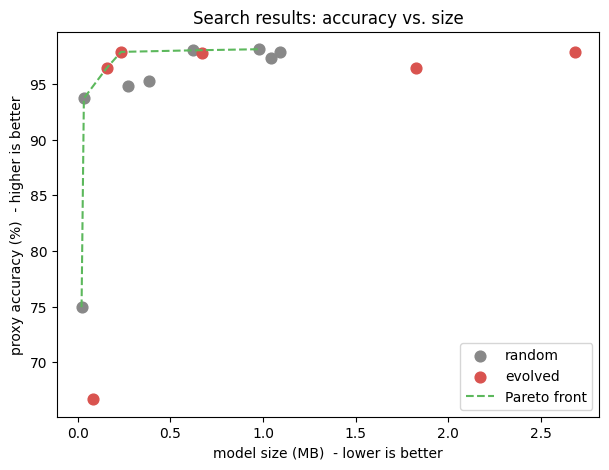

In [12]:
import matplotlib.pyplot as plt

def pareto_front(rows):
    """Architectures not beaten on BOTH accuracy (higher) and size (lower)."""
    front = [r for r in rows
             if not any(o is not r and o["acc"] >= r["acc"] and o["size"] <= r["size"]
                        for o in rows)]
    return sorted(front, key=lambda r: r["size"])

front = pareto_front(results)
print("Pareto-optimal architectures (best accuracy for their size):")
for r in front:
    print(f"  {arch_str(r['arch']):<12} acc={r['acc']:5.2f}%  size={r['size']:5.2f}MB")

fig, ax = plt.subplots(figsize=(7, 5))
for src, color in [("random", "#888"), ("evolved", "#d9534f")]:
    pts = [r for r in results if r["source"] == src]
    ax.scatter([r["size"] for r in pts], [r["acc"] for r in pts], c=color, label=src, s=60)
ax.plot([r["size"] for r in front], [r["acc"] for r in front], "--", c="#5cb85c",
        label="Pareto front")
ax.set_xlabel("model size (MB)  - lower is better")
ax.set_ylabel("proxy accuracy (%)  - higher is better")
ax.set_title("Search results: accuracy vs. size")
ax.legend(); plt.show()

## 8. Pick a winner & compare before vs. after

A realistic NAS objective: **the most accurate architecture that is no bigger than a sensible
hand-designed baseline**. That asks "can the search match a human's default while staying within
the same size budget?"

In [13]:
BASELINE_ARCH = {"depth": 3, "width": 32, "kernel": 3}   # a sensible hand-designed default
baseline_size = model_size_mb(build_model(BASELINE_ARCH))

# objective: most accurate (by proxy) architecture no bigger than the baseline
in_budget = [r for r in results if r["size"] <= baseline_size]
chosen = max(in_budget or results, key=lambda r: r["acc"])["arch"]

print(f"baseline : {arch_str(BASELINE_ARCH)}  ({baseline_size:.2f}MB)")
print(f"NAS pick : {arch_str(chosen)}")

baseline : d3-w32-k3  (0.38MB)
NAS pick : d4-w12-k3


## 9. Train the finalists fully

The proxy only ranked candidates. Now train both the baseline and the NAS pick **fully** on all
of MNIST to get honest before/after numbers.

In [14]:
print("training baseline ...")
baseline = train(build_model(BASELINE_ARCH), train_loader, epochs=EPOCHS)
base_acc = evaluate(baseline)
print(f"  baseline test_acc={base_acc:.2f}%")

print("training NAS pick ...")
best = train(build_model(chosen), train_loader, epochs=EPOCHS)
best_acc = evaluate(best)
print(f"  NAS pick test_acc={best_acc:.2f}%")

training baseline ...
  baseline test_acc=99.44%
training NAS pick ...
  NAS pick test_acc=99.52%


## 10. Results - size, accuracy & latency, before vs. after

The hand-designed baseline vs. the architecture the search picked, both fully trained.

model                           size   accuracy   CPU latency
-------------------------------------------------------------
baseline (d3-w32-k3)          0.38MB     99.44%        1.30ms
NAS pick (d4-w12-k3)          0.23MB     99.52%        1.14ms

>>> NAS pick: 1.7x smaller, 1.1x faster, +0.08% accuracy vs. the hand-designed baseline.


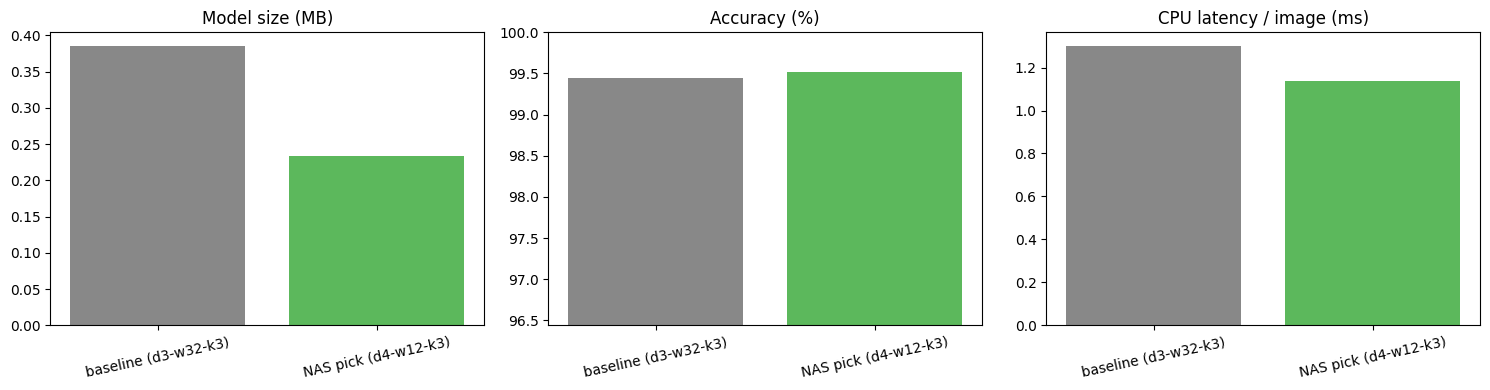

In [15]:
rows = [
    (f"baseline ({arch_str(BASELINE_ARCH)})", model_size_mb(baseline), base_acc, latency_ms(baseline)),
    (f"NAS pick ({arch_str(chosen)})",        model_size_mb(best),     best_acc, latency_ms(best)),
]

print(f"{'model':<26}{'size':>10}{'accuracy':>11}{'CPU latency':>14}")
print("-" * 61)
for name, sz, acc, lat in rows:
    print(f"{name:<26}{sz:>8.2f}MB{acc:>10.2f}%{lat:>12.2f}ms")

b, n = rows
print(f"\n>>> NAS pick: {b[1]/n[1]:.1f}x smaller, {b[3]/n[3]:.1f}x faster, "
      f"{n[2]-b[2]:+.2f}% accuracy vs. the hand-designed baseline.")

names  = [r[0] for r in rows]
sizes  = [r[1] for r in rows]
accs   = [r[2] for r in rows]
lats   = [r[3] for r in rows]
colors = ["#888", "#5cb85c"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(names, sizes, color=colors); ax[0].set_title("Model size (MB)")
ax[1].bar(names, accs,  color=colors); ax[1].set_title("Accuracy (%)"); ax[1].set_ylim(min(accs)-3, 100)
ax[2].bar(names, lats,  color=colors); ax[2].set_title("CPU latency / image (ms)")
for a in ax: a.tick_params(axis="x", rotation=12)
plt.tight_layout(); plt.show()

## 11. Takeaways & things to try

**What you saw:** NAS = a **search space** + a **search strategy** + a cheap way to **score**
candidates. Random search is a surprisingly strong baseline; a little **evolution** (mutate the
best) pushes further into good regions of the space. Scoring with a low-fidelity **proxy** (few
epochs, a data subset, size instead of latency) is what makes trying many architectures
affordable.

**Experiment (edit and re-run):**
- Grow the **search space**: add a `width` of 48/64, or a 4th gene (e.g. number of FC units).
- Change the **objective**: pick the smallest model within 0.5% of the best accuracy instead.
- Spend more on the **proxy** (`SEARCH_EPOCHS`, `SEARCH_SUBSET`) - does the ranking get more
  reliable? Proxies are noisy.
- Run **random search only** at the same budget (set `EVO_GENS = 0`) - does evolution still win?

**Why it matters for the edge:** the best architecture depends on the hardware budget. NAS
automates the accuracy-vs-cost trade-off instead of hand-tuning it, and it composes with the
others: search a good architecture, then **prune**, **distill** and **quantize** it.